### **Estudo do Alinhamento entre as Imagens (12/03/2026).**
1. Reavaliar o alinhamento com recorte. Observar as transformações img(i) = M*img(i+1).
2. Aplicar a transformação para todas as imagens, antes do recorte, através das escalas acumuladas.
3. Recortar os pixels excedentes.
4. Gerar mapa binário de pixels selecionados a partir do laplaciano.

**ECC Transform:** Avalia o coeficiente de correlação entre duas imagens (-1, 1).

In [62]:
import cv2 as cv
import numpy as np
from IPython.display import Image

In [49]:
img1 = cv.imread('../images/ordered/20.jpg')
img2 = cv.imread('../images/ordered/40.jpg')


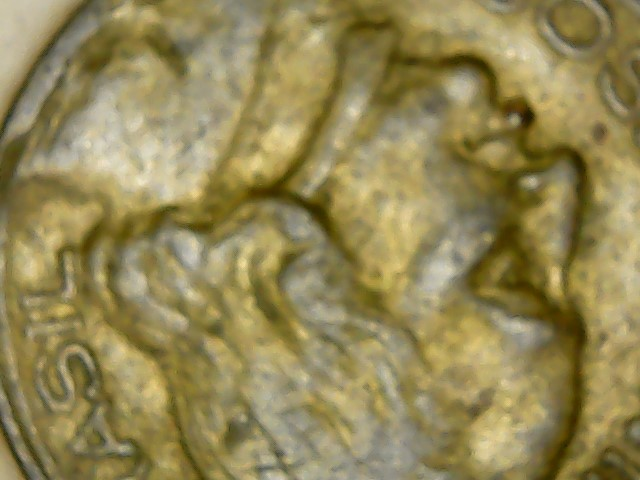

In [64]:
Image('../images/ordered/20.jpg')

In [50]:
# Visualização.
cv.imshow('Image 1', img1)
cv.waitKey(0)
cv.destroyAllWindows()

In [51]:
# Estimativa.
width, height = img1.shape[1], img1.shape[0]

img1_gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
img2_gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

warp_mode = cv.MOTION_AFFINE
criteria = (cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 500, 1e-15)
warp_matrix = np.eye(2, 3, dtype=np.float32)

(cc, warp_matrix) = cv.findTransformECC(img1_gray, img2_gray, warp_matrix, warp_mode, criteria)

In [52]:
print(f"Coeficiente de Correlação: {cc:.4f}")

Coeficiente de Correlação: 0.9299


In [53]:
# Matriz de transformação.
print("Transformation Matrix: \n", warp_matrix)

# Escala.
scale_x = np.sqrt(warp_matrix[0, 0]**2 + warp_matrix[1, 0]**2)
scale_y = np.sqrt(warp_matrix[0, 1]**2 + warp_matrix[1, 1]**2)

M = np.array([[warp_matrix[0, 0], warp_matrix[0, 1]], [warp_matrix[1, 0], warp_matrix[1, 1]]])
det = np.linalg.det(M)

print("\nM: \n", M)
print(f'\nDeterminant (Total Scale): {det:.4f}')
print(f'Scale X: {scale_x:.4f}')
print(f'Scale Y: {scale_y:.4f}')

Transformation Matrix: 
 [[ 1.0640267e+00  7.1655864e-05 -2.6938696e+01]
 [ 2.0324296e-04  1.0636960e+00 -2.6136414e+01]]

M: 
 [[1.0640267e+00 7.1655864e-05]
 [2.0324296e-04 1.0636960e+00]]

Determinant (Total Scale): 1.1318
Scale X: 1.0640
Scale Y: 1.0637


In [54]:
img_aligned = cv.warpAffine(img2_gray, warp_matrix, (width, height), 
                                         flags=cv.INTER_LINEAR + cv.WARP_INVERSE_MAP,
                                         borderMode=cv.BORDER_CONSTANT, borderValue=(0,0,0))

In [ ]:
common_mask = np.ones((height, width), dtype=np.uint8) * 255

# Continuar aplicação do filtro de contorno.

In [78]:
img_aligned # Há bordas.

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(480, 640), dtype=uint8)

In [72]:
img1_gray-img_aligned #uint

array([[196, 196, 195, ..., 100,  99,  98],
       [197, 197, 196, ..., 107, 107, 109],
       [198, 198, 197, ..., 111, 109, 113],
       ...,
       [170, 169, 168, ..., 103, 106, 112],
       [170, 169, 168, ..., 100, 105, 117],
       [170, 169, 169, ..., 100, 108, 124]], shape=(480, 640), dtype=uint8)

In [77]:
ref = img1_gray.astype(np.float32)
warped = img_aligned.astype(np.float32)

(ref-warped) # float32

array([[196., 196., 195., ..., 100.,  99.,  98.],
       [197., 197., 196., ..., 107., 107., 109.],
       [198., 198., 197., ..., 111., 109., 113.],
       ...,
       [170., 169., 168., ..., 103., 106., 112.],
       [170., 169., 168., ..., 100., 105., 117.],
       [170., 169., 169., ..., 100., 108., 124.]],
      shape=(480, 640), dtype=float32)

In [76]:
E = (ref-warped)
N = width*height

frobenius_norm = np.linalg.norm(E, ord='fro')

RMSE = round(float(frobenius_norm/np.sqrt(N)), 2)

print(f"Erro médio quadrático: {RMSE} - desvio médio esperado por pixel na unidade da imagem.")

Erro médio quadrático: 49.86 - desvio médio esperado por pixel na unidade da imagem.


###### **Conclusão:** Se as imagens estão em tons de cinza numa escala de 0 a 255 (uint8) e o cálculo resultou em um $RMSE = 42.64$. Isso significa que, em média, após o algoritmo aplicar o zoom e a translação, cada pixel da imagem alinhada está errando a cor do pixel correspondente na imagem de referência em cerca de 42.64 tons de cinza.

In [59]:
# Comparativo visual - Note que o tamanho da nova imagem está diferente. 
cv.imshow('Aligned Image', img_aligned)
cv.imshow('Reference Image', img1_gray)
cv.waitKey(0)
cv.destroyAllWindows()